## 3 Statement Financial Model Automation

# Purpose

Builds Income Statement, Balance Sheet, Cash Flow, Debt/Depreciation/Interest/Working Capital schedules, and KPIs (DSCR, IRR, NPV, Payback) from an
assumptions & drivers, and saves each as a CSV in output.

In [1]:
pip install numpy-financial

Note: you may need to restart the kernel to use updated packages.


In [2]:
# numpy-financial is the standard tool for IRR/NPV in Python finance work

In [3]:
import pandas as pd
import numpy as np
import os
import numpy_financial as npf
import matplotlib.pyplot as plt

In [4]:
INPUT_CSV = "project_2_assumptions_and_drivers.csv"
OUTPUT_DIR = "output"

In [5]:
YEARS = [f"Year {i}" for i in range(1, 6)]

driver_df = pd.read_csv(INPUT_CSV, encoding="latin1")

def get_yearly_row(assumption_name):
    match = driver_df["Assumption"].astype(str).str.strip() == assumption_name.strip()
    row = driver_df.loc[match, YEARS].iloc[0]
    is_percent = row.astype(str).str.contains("%").any()

    row = row.astype(str).str.replace("[%,]", "", regex=True).str.strip()
    row = row.replace("-", "0")
    row = row.astype(float)

    if is_percent:
        row = row / 100.0
    return row


def get_single_value(assumption_name):
    match = driver_df["Assumption"].astype(str).str.strip() == assumption_name.strip()
    raw_original = str(driver_df.loc[match, "Year 1"].iloc[0])
    raw = raw_original.replace("?", "").replace(",", "").replace("%", "").strip()
    value = float(raw.split()[0])

    if "%" in raw_original:
        value = value / 100.0
    return value


def revenue_series():
    growth = get_yearly_row("Revenue Growth")
    opening_revenue = get_single_value("Opening Revenue")

    revenue = {}
    previous_year_revenue = opening_revenue
    for year in YEARS:
        previous_year_revenue = previous_year_revenue * (1 + growth[year])
        revenue[year] = previous_year_revenue
    return pd.Series(revenue)

In [6]:
import os
print("Current folder:", os.getcwd())
print("Files here:", os.listdir())
# This is to check the current files Panda is looking in.

Current folder: C:\Users\USER\Downloads\Portfolio\Project 2 fin model automation
Files here: ['.ipynb_checkpoints', 'assumptions.py', 'Financial Model Automation.ipynb', 'output', 'project 2_assumptions and drivers.xlsx', 'project_2_assumptions_and_drivers.csv', '__pycache__']


In [7]:
#Depreciation Schedule
capex = get_yearly_row("Capital Expenditure ")
depreciation_rate = get_yearly_row("Depreciation (% of Gross PPE)")
opening_gross_ppe = get_single_value("Opening Gross PPE")

# We'll build the schedule one year at a time and collect the rows in a list.
rows = []
gross_ppe_opening = opening_gross_ppe
accumulated_depreciation = 0.0

for year in YEARS:
    year_capex = capex[year]
    gross_ppe_closing = gross_ppe_opening + year_capex

    depreciation_this_year = gross_ppe_closing * depreciation_rate[year]
    accumulated_depreciation += depreciation_this_year

    net_ppe = gross_ppe_closing - accumulated_depreciation

    rows.append({"Year": year, "Opening Gross PPE": gross_ppe_opening, "Capex": year_capex, "Closing Gross PPE": gross_ppe_closing,
        "Depreciation": depreciation_this_year, "Accumulated Depreciation": accumulated_depreciation, "Net PPE": net_ppe, })

    # This year's closing balance becomes next year's opening balance.
    gross_ppe_opening = gross_ppe_closing

depreciation_schedule = pd.DataFrame(rows).set_index("Year")

if __name__ == "__main__":
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    depreciation_schedule.to_csv(f"{OUTPUT_DIR}/depreciation_schedule.csv")

    print(" Depreciation Schedule ")
    print(depreciation_schedule.round(0))
    print(f"\nSaved to '{OUTPUT_DIR}/depreciation_schedule.csv'.")

 Depreciation Schedule 
        Opening Gross PPE     Capex  Closing Gross PPE  Depreciation  \
Year                                                                   
Year 1           450000.0  120000.0           570000.0       45600.0   
Year 2           570000.0   85000.0           655000.0       52400.0   
Year 3           655000.0   60000.0           715000.0       57200.0   
Year 4           715000.0   45000.0           760000.0       60800.0   
Year 5           760000.0   35000.0           795000.0       63600.0   

        Accumulated Depreciation   Net PPE  
Year                                        
Year 1                   45600.0  524400.0  
Year 2                   98000.0  557000.0  
Year 3                  155200.0  559800.0  
Year 4                  216000.0  544000.0  
Year 5                  279600.0  515400.0  

Saved to 'output/depreciation_schedule.csv'.


In [8]:
# Debt schedule
new_debt_raised = get_yearly_row("New Debt Raised (?'000)")
opening_debt = get_single_value("Opening Debt")
 
# Total amount of debt that will ever exist across the 5 years.
total_debt_pool = opening_debt + new_debt_raised.sum()
annual_principal_repayment = total_debt_pool / 5
 
rows = []
debt_opening = opening_debt
 
for year in YEARS:
    year_new_debt = new_debt_raised[year]
    debt_before_repayment = debt_opening + year_new_debt
 
    # Don't repay more than what's actually outstanding.
    principal_repayment = min(annual_principal_repayment, debt_before_repayment)
    debt_closing = debt_before_repayment - principal_repayment
 
    rows.append({ "Year": year, "Opening Debt": debt_opening, "New Debt Raised": year_new_debt, "Principal Repayment": principal_repayment,
        "Closing Debt": debt_closing, })
 
    debt_opening = debt_closing
 
debt_schedule = pd.DataFrame(rows).set_index("Year")
 
if __name__ == "__main__":
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    debt_schedule.to_csv(f"{OUTPUT_DIR}/debt_schedule.csv")
 
    print(" Debt Schedule ")
    print(debt_schedule.round(0))
    print(f"\nSaved to '{OUTPUT_DIR}/debt_schedule.csv'.")
 

 Debt Schedule 
        Opening Debt  New Debt Raised  Principal Repayment  Closing Debt
Year                                                                    
Year 1      200000.0         150000.0              80000.0      270000.0
Year 2      270000.0          50000.0              80000.0      240000.0
Year 3      240000.0              0.0              80000.0      160000.0
Year 4      160000.0              0.0              80000.0       80000.0
Year 5       80000.0              0.0              80000.0           0.0

Saved to 'output/debt_schedule.csv'.


In [9]:
#Interest schedule
debt_schedule = pd.read_csv(f"{OUTPUT_DIR}/debt_schedule.csv", index_col="Year")
interest_rate = get_yearly_row("Interest Rate on Debt")
 
rows = []
for year in YEARS:
    opening_debt = debt_schedule.loc[year, "Opening Debt"]
    new_debt = debt_schedule.loc[year, "New Debt Raised"]
    closing_debt = debt_schedule.loc[year, "Closing Debt"]
 
    average_debt_balance = (opening_debt + new_debt + closing_debt) / 2
    interest_expense = average_debt_balance * interest_rate[year]
 
    rows.append({ "Year": year, "Average Debt Balance": average_debt_balance, "Interest Rate": interest_rate[year], 
                  "Interest Expense": interest_expense,})
 
interest_schedule = pd.DataFrame(rows).set_index("Year")
 
if __name__ == "__main__":
    interest_schedule.to_csv(f"{OUTPUT_DIR}/interest_schedule.csv")
 
    print(" Interest Schedule ")
    print(interest_schedule.round(0))
    print(f"\nSaved to '{OUTPUT_DIR}/interest_schedule.csv'.")

 Interest Schedule 
        Average Debt Balance  Interest Rate  Interest Expense
Year                                                         
Year 1              310000.0            0.0           43400.0
Year 2              280000.0            0.0           39200.0
Year 3              200000.0            0.0           27000.0
Year 4              120000.0            0.0           15600.0
Year 5               40000.0            0.0            5000.0

Saved to 'output/interest_schedule.csv'.


In [10]:
#working capital schedule
revenue = revenue_series()
ar_days = get_yearly_row("Accounts Receivable Days")
inv_days = get_yearly_row("Inventory Days")
ap_days = get_yearly_row("Accounts Payable Days")
ebitda_margin = get_single_value("EBITDA margin")
opening_revenue = get_single_value("Opening Revenue")
 
# --- Year 0 baseline ---
cogs_year0 = opening_revenue * (1 - ebitda_margin)
ar_year0 = opening_revenue * ar_days["Year 1"] / 365
inventory_year0 = cogs_year0 * inv_days["Year 1"] / 365
ap_year0 = cogs_year0 * ap_days["Year 1"] / 365
nwc_year0 = ar_year0 + inventory_year0 - ap_year0
 
rows = [{ "Year": "Year 0", "Accounts Receivable": ar_year0, "Inventory": inventory_year0, "Accounts Payable": ap_year0,
    "Net Working Capital": nwc_year0,  "Change in NWC": None, }]
previous_nwc = nwc_year0
for year in YEARS:
    cogs = revenue[year] * (1 - ebitda_margin)
 
    accounts_receivable = revenue[year] * ar_days[year] / 365
    inventory = cogs * inv_days[year] / 365
    accounts_payable = cogs * ap_days[year] / 365
    net_working_capital = accounts_receivable + inventory - accounts_payable
 
    change_in_nwc = net_working_capital - previous_nwc
 
    rows.append({ "Year": year, "Accounts Receivable": accounts_receivable, "Inventory": inventory, "Accounts Payable": accounts_payable,
        "Net Working Capital": net_working_capital, "Change in NWC": change_in_nwc,})
    previous_nwc = net_working_capital
 
working_capital_schedule = pd.DataFrame(rows).set_index("Year")
 
if __name__ == "__main__":
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    working_capital_schedule.to_csv(f"{OUTPUT_DIR}/working_capital_schedule.csv")
 
    print(" Working Capital Schedule ")
    print(working_capital_schedule.round(0))
    print(f"\nSaved to '{OUTPUT_DIR}/working_capital_schedule.csv'.")

 Working Capital Schedule 
        Accounts Receivable  Inventory  Accounts Payable  Net Working Capital  \
Year                                                                            
Year 0              47945.0    46233.0           30822.0              63356.0   
Year 1              55137.0    53168.0           35445.0              72860.0   
Year 2              61753.0    56901.0           39699.0              78956.0   
Year 3              65988.0    61136.0           45124.0              82000.0   
Year 4              69171.0    62883.0           50306.0              81747.0   
Year 5              71099.0    63323.0           53324.0              81098.0   

        Change in NWC  
Year                   
Year 0            NaN  
Year 1         9503.0  
Year 2         6097.0  
Year 3         3044.0  
Year 4         -252.0  
Year 5         -650.0  

Saved to 'output/working_capital_schedule.csv'.


## Financial Statements

In [11]:
# Income statement
depreciation_schedule = pd.read_csv(f"{OUTPUT_DIR}/depreciation_schedule.csv", index_col="Year")
interest_schedule = pd.read_csv(f"{OUTPUT_DIR}/interest_schedule.csv", index_col="Year")
 
revenue = revenue_series()
ebitda_margin = get_single_value("EBITDA margin")
tax_rate = get_yearly_row("Corporate Tax Rate")
dividend_payout_ratio = get_yearly_row("Dividend Payout Ratio")
 
rows = []
for year in YEARS:
    year_revenue = revenue[year]
    ebitda = year_revenue * ebitda_margin
    depreciation = depreciation_schedule.loc[year, "Depreciation"]
    ebit = ebitda - depreciation
 
    interest_expense = interest_schedule.loc[year, "Interest Expense"]
    ebt = ebit - interest_expense
 
    tax = max(ebt, 0) * tax_rate[year]
    net_income = ebt - tax
 
    dividends = max(net_income, 0) * dividend_payout_ratio[year]
    retained_earnings_addition = net_income - dividends
 
    rows.append({ "Year": year, "Revenue": year_revenue, "EBITDA": ebitda, "Depreciation": depreciation, "EBIT": ebit, "Interest Expense": interest_expense,
        "EBT": ebt, "Tax": tax, "Net Income": net_income, "Dividends": dividends, "Retained Earnings Addition": retained_earnings_addition, })
 
income_statement = pd.DataFrame(rows).set_index("Year")
 
if __name__ == "__main__":
    income_statement.to_csv(f"{OUTPUT_DIR}/income_statement.csv")
 
    print(" Income Statement ")
    print(income_statement.round(0))
    print(f"\nSaved to '{OUTPUT_DIR}/income_statement.csv'.")

 Income Statement 
         Revenue    EBITDA  Depreciation      EBIT  Interest Expense  \
Year                                                                   
Year 1  575000.0  143750.0       45600.0   98150.0           43400.0   
Year 2  644000.0  161000.0       52400.0  108600.0           39200.0   
Year 3  708400.0  177100.0       57200.0  119900.0           27000.0   
Year 4  765072.0  191268.0       60800.0  130468.0           15600.0   
Year 5  810976.0  202744.0       63600.0  139144.0            5000.0   

             EBT      Tax  Net Income  Dividends  Retained Earnings Addition  
Year                                                                          
Year 1   54750.0  16425.0     38325.0     7665.0                     30660.0  
Year 2   69400.0  20820.0     48580.0    12145.0                     36435.0  
Year 3   92900.0  27870.0     65030.0    19509.0                     45521.0  
Year 4  114868.0  34460.0     80408.0    28143.0                     52265.0  
Ye

In [12]:
# cash flow statement
income_statement = pd.read_csv(f"{OUTPUT_DIR}/income_statement.csv", index_col="Year")
working_capital_schedule = pd.read_csv(f"{OUTPUT_DIR}/working_capital_schedule.csv", index_col="Year")
debt_schedule = pd.read_csv(f"{OUTPUT_DIR}/debt_schedule.csv", index_col="Year")
 
capex = get_yearly_row("Capital Expenditure ")
opening_cash = get_single_value("Opening Cash")
 
rows = []
cash_balance = opening_cash
 
for year in YEARS:
    net_income = income_statement.loc[year, "Net Income"]
    depreciation = income_statement.loc[year, "Depreciation"]
    change_in_nwc = working_capital_schedule.loc[year, "Change in NWC"]
 
    cfo = net_income + depreciation - change_in_nwc
    cfi = -capex[year]
 
    new_debt_raised = debt_schedule.loc[year, "New Debt Raised"]
    principal_repayment = debt_schedule.loc[year, "Principal Repayment"]
    dividends_paid = income_statement.loc[year, "Dividends"]
    cff = new_debt_raised - principal_repayment - dividends_paid
 
    net_change_in_cash = cfo + cfi + cff
    cash_balance = cash_balance + net_change_in_cash
 
    rows.append({ "Year": year, "CFO": cfo, "CFI": cfi, "CFF": cff, "Net Change in Cash": net_change_in_cash, "Closing Cash Balance": cash_balance,})
 
cash_flow_statement = pd.DataFrame(rows).set_index("Year")
 
if __name__ == "__main__":
    cash_flow_statement.to_csv(f"{OUTPUT_DIR}/cash_flow_statement.csv")
 
    print(" Cash Flow Statement ")
    print(cash_flow_statement.round(0))
    print(f"\nSaved to '{OUTPUT_DIR}/cash_flow_statement.csv'.")
 

 Cash Flow Statement 
             CFO       CFI       CFF  Net Change in Cash  Closing Cash Balance
Year                                                                          
Year 1   74422.0 -120000.0   62335.0             16757.0               76757.0
Year 2   94883.0  -85000.0  -42145.0            -32262.0               44495.0
Year 3  119186.0  -60000.0  -99509.0            -40323.0                4172.0
Year 4  141460.0  -45000.0 -108143.0            -11683.0               -7510.0
Year 5  158151.0  -35000.0 -117560.0              5590.0               -1920.0

Saved to 'output/cash_flow_statement.csv'.


In [13]:
# Balance sheet
working_capital_schedule = pd.read_csv(f"{OUTPUT_DIR}/working_capital_schedule.csv", index_col="Year")
depreciation_schedule = pd.read_csv(f"{OUTPUT_DIR}/depreciation_schedule.csv", index_col="Year")
debt_schedule = pd.read_csv(f"{OUTPUT_DIR}/debt_schedule.csv", index_col="Year")
cash_flow_statement = pd.read_csv(f"{OUTPUT_DIR}/cash_flow_statement.csv", index_col="Year")
income_statement = pd.read_csv(f"{OUTPUT_DIR}/income_statement.csv", index_col="Year")
 
opening_cash = get_single_value("Opening Cash")
opening_gross_ppe = get_single_value("Opening Gross PPE")
opening_debt = get_single_value("Opening Debt")
 
# --- Year 0 opening balance sheet (used to derive Opening Equity) ---
ar_year0 = working_capital_schedule.loc["Year 0", "Accounts Receivable"]
inventory_year0 = working_capital_schedule.loc["Year 0", "Inventory"]
ap_year0 = working_capital_schedule.loc["Year 0", "Accounts Payable"]
 
total_assets_year0 = opening_cash + ar_year0 + inventory_year0 + opening_gross_ppe
total_liabilities_year0 = ap_year0 + opening_debt
opening_equity = total_assets_year0 - total_liabilities_year0   # the plug
 
rows = [{ "Year": "Year 0", "Cash": opening_cash, "Accounts Receivable": ar_year0, "Inventory": inventory_year0, "Net PPE": opening_gross_ppe,
    "Total Assets": total_assets_year0, "Accounts Payable": ap_year0, "Debt": opening_debt, "Total Liabilities": total_liabilities_year0,
    "Equity": opening_equity, "Total Liabilities & Equity": total_liabilities_year0 + opening_equity, 
    "Balance Check": total_assets_year0 - (total_liabilities_year0 + opening_equity),}]
 
# --- Year 1 to Year 5 ---
running_equity = opening_equity
for year in YEARS:
    cash = cash_flow_statement.loc[year, "Closing Cash Balance"]
    accounts_receivable = working_capital_schedule.loc[year, "Accounts Receivable"]
    inventory = working_capital_schedule.loc[year, "Inventory"]
    net_ppe = depreciation_schedule.loc[year, "Net PPE"]
    total_assets = cash + accounts_receivable + inventory + net_ppe
 
    accounts_payable = working_capital_schedule.loc[year, "Accounts Payable"]
    debt = debt_schedule.loc[year, "Closing Debt"]
    total_liabilities = accounts_payable + debt
 
    retained_earnings_addition = income_statement.loc[year, "Retained Earnings Addition"]
    running_equity = running_equity + retained_earnings_addition
 
    total_liabilities_and_equity = total_liabilities + running_equity
    balance_check = total_assets - total_liabilities_and_equity
 
    rows.append({ "Year": year, "Cash": cash, "Accounts Receivable": accounts_receivable, "Inventory": inventory, "Net PPE": net_ppe,
        "Total Assets": total_assets, "Accounts Payable": accounts_payable, "Debt": debt, "Total Liabilities": total_liabilities,
        "Equity": running_equity, "Total Liabilities & Equity": total_liabilities_and_equity, "Balance Check": balance_check,})
 
balance_sheet = pd.DataFrame(rows).set_index("Year")
 
if __name__ == "__main__":
    balance_sheet.to_csv(f"{OUTPUT_DIR}/balance_sheet.csv")
 
    print("Balance Sheet (Balance Check column should be ~0)")
    print(balance_sheet.round(0))
    print(f"\nSaved to '{OUTPUT_DIR}/balance_sheet.csv'.")

Balance Sheet (Balance Check column should be ~0)
           Cash  Accounts Receivable  Inventory   Net PPE  Total Assets  \
Year                                                                      
Year 0  60000.0              47945.0    46233.0  450000.0      604178.0   
Year 1  76757.0              55137.0    53168.0  524400.0      709461.0   
Year 2  44495.0              61753.0    56901.0  557000.0      720150.0   
Year 3   4172.0              65988.0    61136.0  559800.0      691096.0   
Year 4  -7510.0              69171.0    62883.0  544000.0      668543.0   
Year 5  -1920.0              71099.0    63323.0  515400.0      647902.0   

        Accounts Payable      Debt  Total Liabilities    Equity  \
Year                                                              
Year 0           30822.0  200000.0           230822.0  373356.0   
Year 1           35445.0  270000.0           305445.0  404016.0   
Year 2           39699.0  240000.0           279699.0  440451.0   
Year 3        

In [14]:
# Valuation and KPIs
income_statement = pd.read_csv(f"{OUTPUT_DIR}/income_statement.csv", index_col="Year")
balance_sheet = pd.read_csv(f"{OUTPUT_DIR}/balance_sheet.csv", index_col="Year")
cash_flow_statement = pd.read_csv(f"{OUTPUT_DIR}/cash_flow_statement.csv", index_col="Year")
debt_schedule = pd.read_csv(f"{OUTPUT_DIR}/debt_schedule.csv", index_col="Year")
interest_schedule = pd.read_csv(f"{OUTPUT_DIR}/interest_schedule.csv", index_col="Year")
working_capital_schedule = pd.read_csv(f"{OUTPUT_DIR}/working_capital_schedule.csv", index_col="Year")
 
capex = get_yearly_row("Capital Expenditure ")
discount_rate = get_single_value("Discount rate")
 
# --- DSCR and Free Cash Flow, one year at a time ---
kpi_rows = []
for year in YEARS:
    ebitda = income_statement.loc[year, "EBITDA"]
    tax = income_statement.loc[year, "Tax"]
    change_in_nwc = working_capital_schedule.loc[year, "Change in NWC"]
    year_capex = capex[year]
 
    cfads = ebitda - tax - year_capex - change_in_nwc
    debt_service = (interest_schedule.loc[year, "Interest Expense"]
                     + debt_schedule.loc[year, "Principal Repayment"])
    dscr = cfads / debt_service
 
    net_income = income_statement.loc[year, "Net Income"]
    depreciation = income_statement.loc[year, "Depreciation"]
    free_cash_flow = net_income + depreciation - change_in_nwc - year_capex
 
    kpi_rows.append({ "Year": year, "DSCR": dscr, "Cash Balance": cash_flow_statement.loc[year, "Closing Cash Balance"],
        "Debt Balance": debt_schedule.loc[year, "Closing Debt"], "Free Cash Flow": free_cash_flow, })
 
kpis = pd.DataFrame(kpi_rows).set_index("Year")
 
# --- Equity IRR / NPV / Payback ---
opening_equity = balance_sheet.loc["Year 0", "Equity"]
terminal_equity = balance_sheet.loc["Year 5", "Equity"]
dividends = income_statement["Dividends"]
 
equity_cash_flows = [-opening_equity] + list(dividends.iloc[:-1]) + \
    [dividends.iloc[-1] + terminal_equity]
 
irr_value = npf.irr(equity_cash_flows)
npv_value = npf.npv(discount_rate, equity_cash_flows)
 
# Payback: how many years until cumulative cash flow turns positive.
cumulative_cash_flow = pd.Series(equity_cash_flows).cumsum()
payback_years = next((i for i, v in enumerate(cumulative_cash_flow) if v >= 0), None)
 
summary = { "IRR (Equity)": irr_value, f"NPV (Equity, @{discount_rate:.0%})": npv_value, "Payback Period (yrs)": payback_years, 
    "Opening Equity Investment": opening_equity, "Final Cash Balance": cash_flow_statement["Closing Cash Balance"].iloc[-1],
    "Final Debt Balance": debt_schedule["Closing Debt"].iloc[-1],}
 
if __name__ == "__main__":
    kpis.to_csv(f"{OUTPUT_DIR}/kpis.csv")
    pd.DataFrame(summary.items(), columns=["Metric", "Value"]).to_csv(
        f"{OUTPUT_DIR}/summary_kpis.csv", index=False)
 
    print("Per-Year KPIs")
    print(kpis.round(2))
    print("\n Summary Valuation Metrics")
    for key, value in summary.items():
        print(f"{key}: {value:,.2f}" if isinstance(value, (int, float)) else f"{key}: {value}")
 
    print(f"\nSaved to '{OUTPUT_DIR}/kpis.csv' and '{OUTPUT_DIR}/summary_kpis.csv'.")

Per-Year KPIs
        DSCR  Cash Balance  Debt Balance  Free Cash Flow
Year                                                    
Year 1 -0.02      76756.58      270000.0       -45578.42
Year 2  0.41      44495.00      240000.0         9883.42
Year 3  0.81       4172.44      160000.0        59186.44
Year 4  1.17      -7510.31       80000.0        96459.91
Year 5  1.51      -1920.01           0.0       123150.64

 Summary Valuation Metrics
IRR (Equity): 0.14
NPV (Equity, @15%): -14,305.15
Payback Period (yrs): 5.00
Opening Equity Investment: 373,356.16
Final Cash Balance: -1,920.01
Final Debt Balance: 0.00

Saved to 'output/kpis.csv' and 'output/summary_kpis.csv'.


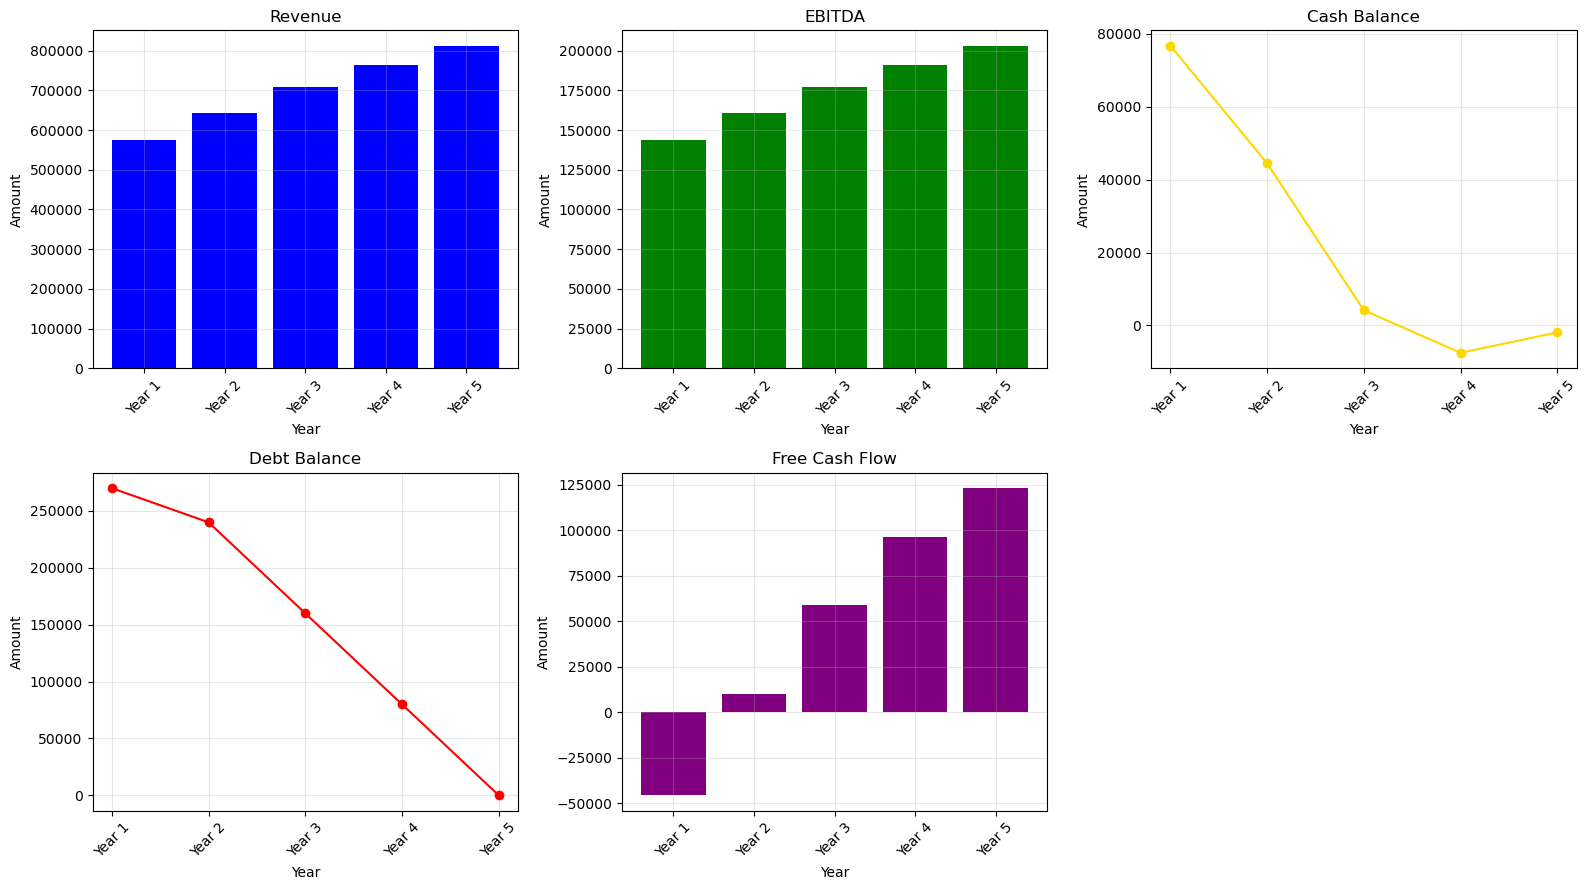

Individual charts saved to 'output/charts/'.
Combined dashboard saved to 'output/charts_dashboard.png'.


In [15]:
#Charts
CHARTS_DIR = f"{OUTPUT_DIR}/charts"

def load_data(output_dir=OUTPUT_DIR):
    income_statement = pd.read_csv(f"{output_dir}/income_statement.csv", index_col="Year")
    debt_schedule = pd.read_csv(f"{output_dir}/debt_schedule.csv", index_col="Year")
    kpis = pd.read_csv(f"{output_dir}/kpis.csv", index_col="Year")
    return income_statement, debt_schedule, kpis
 
def plot_single(years, values, title, kind="bar", color= 'blue', save_path=None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    if kind == "bar":
        ax.bar(years, values, color=color)
    else:
        ax.plot(years, values, marker="o", color=color)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Year")
    ax.set_ylabel("Amount (₦ Millions)")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.close(fig) #this prevents showing the charts as a single chart on the notebook but is downloaded individually
 
def plot_dashboard(years, series_dict, save_path):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    for ax, (title, (values, kind, color)) in zip(axes, series_dict.items()):
        if kind == "bar":
            ax.bar(years, values, color=color)
        else:
            ax.plot(years, values, marker="o", color=color)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)
        ax.set_xlabel("Year")
        ax.set_ylabel("Amount")

    axes[-1].axis("off")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show() # this is to show the chart on the notebook as a dashboard and is also downloadable
    plt.close(fig)
 
if __name__ == "__main__":
    os.makedirs(CHARTS_DIR, exist_ok=True)
    income_statement, debt_schedule, kpis = load_data()
    years = income_statement.index.tolist()
 
    series = {"Revenue": (income_statement["Revenue"].values, "bar", "blue"), "EBITDA": (income_statement["EBITDA"].values, "bar", "GREEN"),
        "Cash Balance": (kpis["Cash Balance"].values, "line", "GOLD"), "Debt Balance": (debt_schedule["Closing Debt"].values, "line", "RED"),
        "Free Cash Flow": (kpis["Free Cash Flow"].values, "bar", "PURPLE"),}
 
    for title, (values, kind, color) in series.items():
        fname = title.lower().replace(" ", "_")
        plot_single(years, values, title, kind, color, f"{CHARTS_DIR}/{fname}.png")
 
    plot_dashboard(years, series, f"{OUTPUT_DIR}/charts_dashboard.png")
 
    print(f"Individual charts saved to '{CHARTS_DIR}/'.")
    print(f"Combined dashboard saved to '{OUTPUT_DIR}/charts_dashboard.png'.")

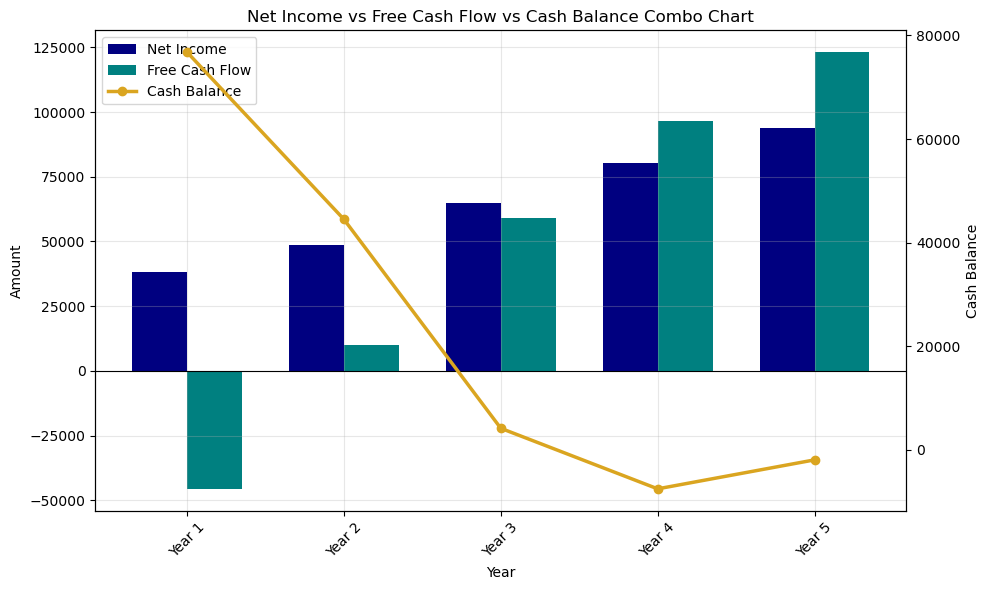

Saved to 'output/charts/combo_chart.png'.


In [18]:
# Combo chart: Net Income & Free Cash Flow (bars) vs Cash Balance (line)
income_statement = pd.read_csv(f"{OUTPUT_DIR}/income_statement.csv", index_col="Year")
kpis = pd.read_csv(f"{OUTPUT_DIR}/kpis.csv", index_col="Year")

years = income_statement.index.tolist()
net_income = income_statement["Net Income"].values
free_cash_flow = kpis["Free Cash Flow"].values
cash_balance = kpis["Cash Balance"].values

fig, ax1 = plt.subplots(figsize=(10, 6))

bar_width = 0.35
x = range(len(years))

# Net Income and Free Cash Flow as grouped bars on the left axis.
ax1.bar([i - bar_width / 2 for i in x], net_income, width=bar_width,
        label="Net Income", color= "NAVY")
ax1.bar([i + bar_width / 2 for i in x], free_cash_flow, width=bar_width,
        label="Free Cash Flow", color= "TEAL")
ax1.set_xlabel("Year")
ax1.set_ylabel("Amount")
ax1.set_xticks(list(x))
ax1.set_xticklabels(years, rotation=45)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.grid(alpha=0.3)

# Cash Balance as a line on a secondary right-hand axis (different scale).
ax2 = ax1.twinx()
ax2.plot(x, cash_balance, marker="o", color=GOLD, linewidth=2.5, label="Cash Balance")
ax2.set_ylabel("Cash Balance")

# Combine legends from both axes into one.
bars_labels, bars_handles = ax1.get_legend_handles_labels()
line_labels, line_handles = ax2.get_legend_handles_labels()
ax1.legend(bars_labels + line_labels, bars_handles + line_handles, loc="upper left")

ax1.set_title("Net Income vs Free Cash Flow vs Cash Balance Combo Chart")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/charts/combo_chart.png", dpi=150)
plt.show()
plt.close(fig)

print(f"Saved to '{OUTPUT_DIR}/charts/combo_chart.png'.")